In the previous weeks we've been using Jupyter notebooks to write, execute, and document our Python code. Jupyter notebooks are great for research and prototyping code, but they are not suited for developing Python modules, libraries and applications. Developing that kind of code is best done in an *integrated development environment*, or IDE. Note that IDEs are **not better** than using Jupyter; they simply serve **a different purpose**.

An IDE provides a relatively comprehensive set of features for software development. It typically supports *source-code editing*, *debugging*, and *version control*. Typically, an IDE provides special support for one or more programming languages, allowing for features tailored to a language. Some IDEs can be extended to support additional languages. Frequently used IDEs for Python development are:

* [PyCharm](https://www.jetbrains.com/pycharm/) - An IDE tailored to Python development
* [Visual Studio Code](https://code.visualstudio.com/) - A universal IDE; has excellent Python support via extensions
* [Spyder](https://www.spyder-ide.org/) - A Python research/data science IDE

If you already have (Python) programming experience in e.g. Visual Studio Code or in another IDE, then feel free to use that IDE for the remainder of this course. If not, then follow the steps in the next section for installing and getting acquainted with PyCharm.

*Many IDEs nowadays have options for AI-assisted code completion and code generation. You are welcome to use these features during the course, as long as you take the time to understand the generated code. If you don't understand the generated code, ask a teaching assistant.*

## Installing and Using PyCharm

PyCharm is a cross-platform IDE developed by JetBrains, working on Windows, macOS, and Linux. The core functionality of PyCharm is open-source, and free to use.

You can download and install PyCharm from: <https://www.jetbrains.com/pycharm/download/>.

When you've installed PyCharm, open it and follow the Quick Start Guide on the JetBrains website from *"Create a new project"* up to and including *"Search for usages"*: <https://www.jetbrains.com/help/pycharm/quick-start-guide.html#create-project-from-scratch>

## Errors and Debugging

The term *debugging* was used in engineering and aeronautics before entering the world of computers. The term *bug*, in the sense of defect, dates back at least to 1878 when Thomas Edison wrote *"little faults and difficulties"* in his inventions as *"bugs"*.

To prevent bugs and make finding and fixing bugs easier, make the problem as small and understandable as possible. Organize code into manageable, logically separated components. Good code structure and frequent testing makes writing code and debugging much easier. Don't wait with running your code until you've written the entire program.

But even when you do that, you'll find that bugs are inevitable. Programming isn't just about writing code; a large part of programming is figuring out why the code doesn't do what you expected, and fixing it.

We can distinguish three types of errors:

* **Syntax error** -  Python can't understand the code and shows e.g. `SyntaxError: expected ':'`
* **Runtime error / exception** - Something goes wrong while executing, and Python shows e.g. `IndexError: list index out of range`
* **Logic error** - The code runs, but produces the wrong result, for example: `area = np.pi * r * 2`

The IDE helps finding syntax errors by highlighting them when possible. Runtime errors raise exceptions with an error message, and logic errors produce the wrong output without raising exceptions.

!!!!! TODO


### Error Messages and Tracebacks

Debugging starts with carefully reading relevant parts of the error. A Python runtime error includes a *traceback* and an *error message*. Let's have a look at this error:

In [18]:
import numpy as np


def sum_rows(image):
    return np.sum(image, axis=1)


my_image = np.array([1, 2, 3])
result = sum_rows(my_image)

print(result)

AxisError: axis 1 is out of bounds for array of dimension 1

The error message reads *"AxisError: axis 1 is out of bounds for array of dimension 1"*, so we know that it has something to do with the dimensions of the array, and axis 1 being 'out of bounds'.

The traceback shows us, from top to bottom, the *chain of function calls* that lead to the error: in the line `result = sum_rows(my_image)`, the function `sum_rows(my_image)` was called, which called `np.sum(image, axis=1)`, which called `_wrapreduction(...)`, which called `ufunc.reduce(...)`, which raised the error. As you can see, not all function calls are our own, but NumPy's; you can ignore these, because we may generally expect that we caused the bug ourselves.

So, the cause of the bug is in the combination of `image` and `axis=1` in `np.sum(image, axis=1)`. Let's print the dimensions of `my_image`:

In [13]:
my_image.shape

(3,)

Ah! This is just a one-dimensional array with 3 elements, so `axis=1` makes no sense! Let's fix the bug by making it a two-dimensional array instead:

In [17]:
import numpy as np


def sum_rows(image):
    return np.sum(image, axis=1)


my_image = np.array([[1, 2, 3], [4, 5, 6]])
result = sum_rows(my_image)

print(result)

[ 6 15]


### Debugging Tools

When your code grows larger and more complex, finding and fixing bugs becomes increasingly difficult. For that reason, IDEs have tools to assist in debugging runtime errors and logic errors. The debugging toolset in PyCharm looks like this:

![PyCharm debugging window](images/debugging-window.png)

The bottom-left window shows you the traceback (`_wrapreduction, fromnumeric.py:83` ← `sum, fromnumeric.py:2463` ← `sum_rows: my_script.py:5` ← `<module>, my_script.py:8`), which you can click to jump to the different functions involved in the error.

The bottom-right window shows information about the variables involved in the current scope. In the example above, it shows information about the variable `image`.

The window at the top highlights which line in the code is currently active, and thus triggered the error.

To start the debugger in PyCharm, click the *'Run / Debug Configurations'* button in the top bar, and click the 'bug' symbol for the *'Current File'*:

![PyCharm start debugging](images/debug_my_script.png)

This will execute the code in the current file and show the debugging toolset when it encounters a runtime error during execution.


### Breakpoints and Stepping Through Code

Logic errors don't raise runtime errors. In order to use the debugger for these types of errors, we must place *brakepoints* ourselves.
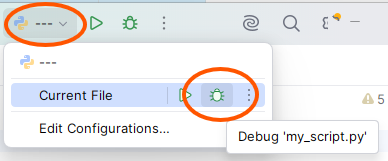